In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Cleaned_data.csv")

In [3]:
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

In [4]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

INPUT_FILE = DATA_DIR / "Cleaned_data.csv"
ENGINEERED_FILE = DATA_DIR / "engineered_data.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Input File:", INPUT_FILE)
print("Figures Folder:", FIGURES_DIR)

Project Root: c:\Users\Aditya Gupta\OneDrive\Desktop\Primeor_Solution
Input File: c:\Users\Aditya Gupta\OneDrive\Desktop\Primeor_Solution\data\Cleaned_data.csv
Figures Folder: c:\Users\Aditya Gupta\OneDrive\Desktop\Primeor_Solution\reports\figures


In [5]:
df.head(3)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit_estimated
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.00,106.14,35.46,Medium,2011,False
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,Apac,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.10,36.04,9.72,Medium,2011,False
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,Emea,Emea,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.00,29.64,8.17,High,2011,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51271 entries, 0 to 51270
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          51271 non-null  object 
 1   order_date        51271 non-null  object 
 2   ship_date         51271 non-null  object 
 3   ship_mode         51271 non-null  object 
 4   customer_name     51271 non-null  object 
 5   segment           51271 non-null  object 
 6   state             51271 non-null  object 
 7   country           51271 non-null  object 
 8   market            51271 non-null  object 
 9   region            51271 non-null  object 
 10  product_id        51271 non-null  object 
 11  category          51271 non-null  object 
 12  sub_category      51271 non-null  object 
 13  product_name      51271 non-null  object 
 14  sales             51271 non-null  int64  
 15  quantity          51271 non-null  int64  
 16  discount          51271 non-null  float6

In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

### Feature Engineering

In [8]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

df["shipping_days"] = (
    df["ship_date"] - df["order_date"]
).dt.days

df[["order_date", "ship_date", "shipping_days"]].head()

,order_date,ship_date,shipping_days
0,2011-01-01,2011-01-06,5
1,2011-01-01,2011-01-08,7
2,2011-01-01,2011-01-05,4
3,2011-01-01,2011-01-05,4
4,2011-01-01,2011-01-08,7


In [9]:
print("Minimum shipping days:", df["shipping_days"].min())
print("Maximum shipping days:", df["shipping_days"].max())
print("Average shipping days:", df["shipping_days"].mean())
print("Median shipping days:", df["shipping_days"].median())

Minimum shipping days: 0
Maximum shipping days: 7
Average shipping days: 3.969339392639114
Median shipping days: 4.0


In [10]:
negative_shipping = df[df["shipping_days"] < 0]

print("Negative shipping-day records:", len(negative_shipping))

Negative shipping-day records: 0


In [11]:
df["profit_margin"] = np.where(
    df["sales"] != 0,
    (df["profit"] / df["sales"]) * 100,
    np.nan
)

df[["sales", "profit", "profit_margin"]].head()

,sales,profit,profit_margin
0,408,106.14,26.01
1,120,36.04,30.03
2,66,29.64,44.91
3,45,-26.05,-57.90
4,114,37.77,33.13


In [12]:
df["year_month"] = df["order_date"].dt.to_period("M").astype(str)

df[["order_date", "year_month"]].head()

,order_date,year_month
0,2011-01-01,2011-01
1,2011-01-01,2011-01
2,2011-01-01,2011-01
3,2011-01-01,2011-01
4,2011-01-01,2011-01


In [13]:
df["quarter"] = "Q" + df["order_date"].dt.quarter.astype(str)

df[["order_date", "quarter"]].head()

,order_date,quarter
0,2011-01-01,Q1
1,2011-01-01,Q1
2,2011-01-01,Q1
3,2011-01-01,Q1
4,2011-01-01,Q1


In [14]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()

df[
    ["order_date", "year", "month", "month_name", "year_month", "quarter"]
].head()

,order_date,year,month,month_name,year_month,quarter
0,2011-01-01,2011,1,January,2011-01,Q1
1,2011-01-01,2011,1,January,2011-01,Q1
2,2011-01-01,2011,1,January,2011-01,Q1
3,2011-01-01,2011,1,January,2011-01,Q1
4,2011-01-01,2011,1,January,2011-01,Q1


In [15]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()

df[
    ["order_date", "year", "month", "month_name", "year_month", "quarter"]
].head()

,order_date,year,month,month_name,year_month,quarter
0,2011-01-01,2011,1,January,2011-01,Q1
1,2011-01-01,2011,1,January,2011-01,Q1
2,2011-01-01,2011,1,January,2011-01,Q1
3,2011-01-01,2011,1,January,2011-01,Q1
4,2011-01-01,2011,1,January,2011-01,Q1


In [16]:
engineered_columns = [
    "shipping_days",
    "profit_margin",
    "year_month",
    "quarter",
    "year",
    "month",
    "month_name"
]

df[engineered_columns].head(10)

,shipping_days,profit_margin,year_month,quarter,year,month,month_name
0,5,26.01,2011-01,Q1,2011,1,January
1,7,30.03,2011-01,Q1,2011,1,January
2,4,44.91,2011-01,Q1,2011,1,January
3,4,-57.90,2011-01,Q1,2011,1,January
4,7,33.13,2011-01,Q1,2011,1,January
5,7,27.89,2011-01,Q1,2011,1,January
6,4,0.99,2011-01,Q1,2011,1,January
7,0,40.00,2011-01,Q1,2011,1,January
8,6,-35.03,2011-01,Q1,2011,1,January
9,4,37.98,2011-01,Q1,2011,1,January


In [17]:
df.to_csv(ENGINEERED_FILE, index=False)

print(f"Engineered dataset saved to: {ENGINEERED_FILE}")
print("Shape:", df.shape)

Engineered dataset saved to: c:\Users\Aditya Gupta\OneDrive\Desktop\Primeor_Solution\data\engineered_data.csv
Shape: (51271, 28)


SHIPPING ANALYSIS

In [18]:
shipping_summary = pd.DataFrame({
    "Metric": [
        "Average Shipping Days",
        "Median Shipping Days",
        "Minimum Shipping Days",
        "Maximum Shipping Days"
    ],
    "Value": [
        df["shipping_days"].mean(),
        df["shipping_days"].median(),
        df["shipping_days"].min(),
        df["shipping_days"].max()
    ]
})

shipping_summary

,Metric,Value
0,Average Shipping Days,3.97
1,Median Shipping Days,4.00
2,Minimum Shipping Days,0.00
3,Maximum Shipping Days,7.00


In [19]:
shipping_by_mode = (
        df.groupby("ship_mode")["shipping_days"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean")
)

shipping_by_mode

,count,mean,median,min,max
ship_mode,,,,,
Same Day,2699,0.04,0.00,0,1
First Class,7504,2.18,2.00,1,3
Second Class,10304,3.23,3.00,2,5
Standard Class,30764,5.00,5.00,4,7


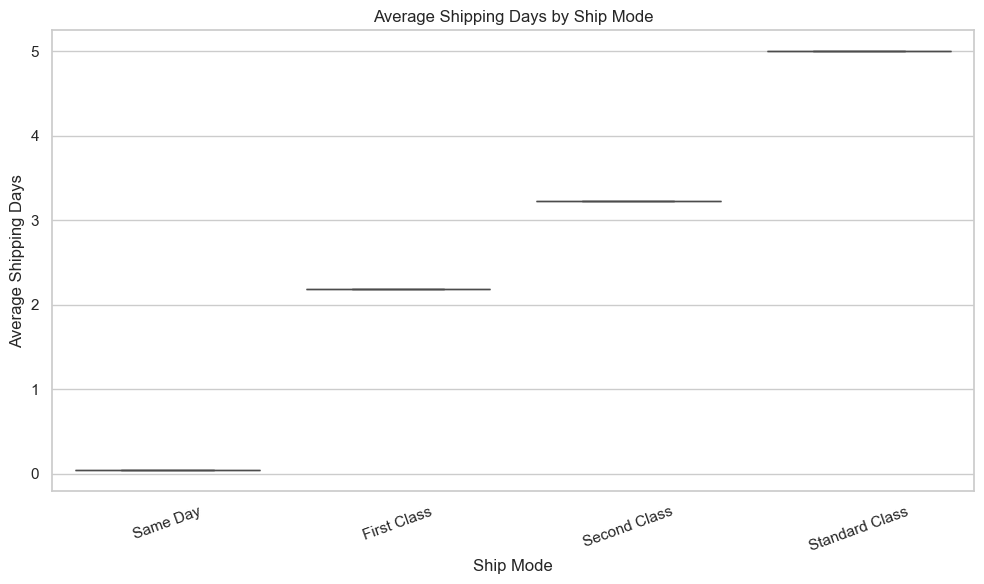

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=shipping_by_mode.reset_index(),
    x='ship_mode',
    y='mean'
)
plt.title("Average Shipping Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation =  20)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR /  "04_shipping_days_by_ship_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
shipping_by_region = (
    df.groupby("region")["shipping_days"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

shipping_by_region

,count,mean,median,min,max
region,,,,,
Central,11115,4.03,4.00,0,7
North,4783,4.03,4.00,0,7
Southeast Asia,3128,4.03,4.00,0,7
Central Asia,2048,4.01,4.00,0,7
Caribbean,1689,3.97,4.00,0,7
South,6643,3.94,4.00,0,7
Oceania,3484,3.93,4.00,0,7
Emea,5026,3.93,4.00,0,7
West,3203,3.93,4.00,0,7


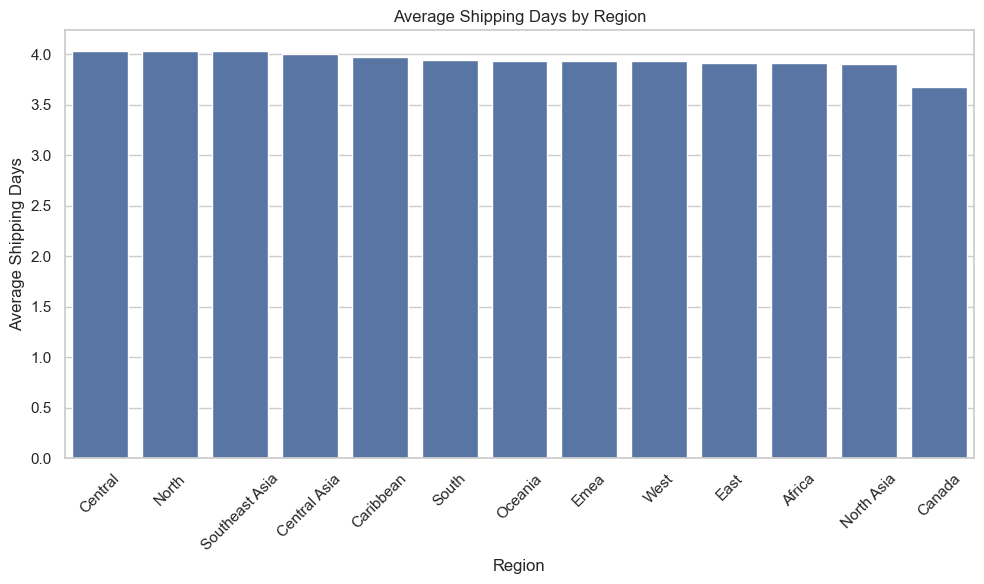

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=shipping_by_region.reset_index(),
    x="region",
    y="mean"
)

plt.title("Average Shipping Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_shipping_days_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
shipping_by_category = (
    df.groupby("category")["shipping_days"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

shipping_by_category

,count,mean,median,min,max
category,,,,,
Furniture,9867,3.99,4.00,0,7
Technology,10137,3.97,4.00,0,7
Office Supplies,31267,3.96,4.00,0,7


In [26]:
Q1_shipping = df["shipping_days"].quantile(0.25)
Q3_shipping = df["shipping_days"].quantile(0.75)

IQR_shipping = Q3_shipping - Q1_shipping

shipping_upper_bound =Q3_shipping + (1.5 *  IQR_shipping)

print("Q1:", Q1_shipping)
print("Q3:", Q3_shipping)
print("IQR:", IQR_shipping)
print("Upper Bound:", shipping_upper_bound)

Q1: 3.0
Q3: 5.0
IQR: 2.0
Upper Bound: 8.0


In [27]:
df["shipping_outlier"] = np.where(
    df["shipping_days"] > shipping_upper_bound,
    "Slow",
    "Normal"
)

df["shipping_outlier"].value_counts()

shipping_outlier
Normal    51271
Name: count, dtype: int64

In [29]:
category_profitability = (
    df.groupby("category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
)

category_profitability["profit_margin"] = (
    category_profitability["profit"]
    / category_profitability["sales"]
    * 100
)

category_profitability.sort_values(
    "profit_margin",
    ascending=False
)

,sales,profit,quantity,profit_margin
category,,,,
Technology,4742975,"663,299.04",35163,13.98
Office Supplies,3786476,"518,327.75",108168,13.69
Furniture,4105771,"286,180.69",34911,6.97


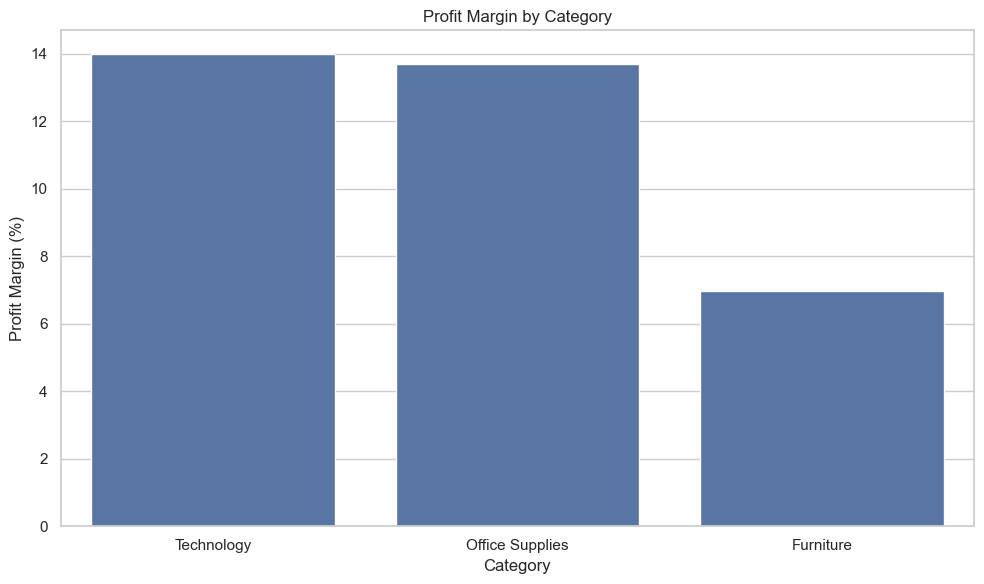

In [30]:
plot_data = (
    category_profitability
    .sort_values("profit_margin", ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="category",
    y="profit_margin"
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_profit_margin_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
subcategory_profitability = (
    df.groupby("sub_category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
)

subcategory_profitability["profit_margin"] = (
    subcategory_profitability["profit"]
    / subcategory_profitability["sales"]
    * 100
)

subcategory_profitability = (
    subcategory_profitability
    .sort_values("profit_margin", ascending=False)
)

subcategory_profitability

,sales,profit,quantity,profit_margin
sub_category,,,,
Paper,244281,"59,195.24",12818,24.23
Labels,73433,"15,009.63",9322,20.44
Envelopes,170875,"29,595.03",8379,17.32
Accessories,748892,"129,568.74",10942,17.30
Copiers,1508370,"258,174.35",7447,17.12
Binders,461842,"72,272.01",21425,15.65
Art,372055,"57,921.90",16299,15.57
Appliances,1011081,"141,680.59",6078,14.01
Fasteners,83240,"11,522.02",8388,13.84


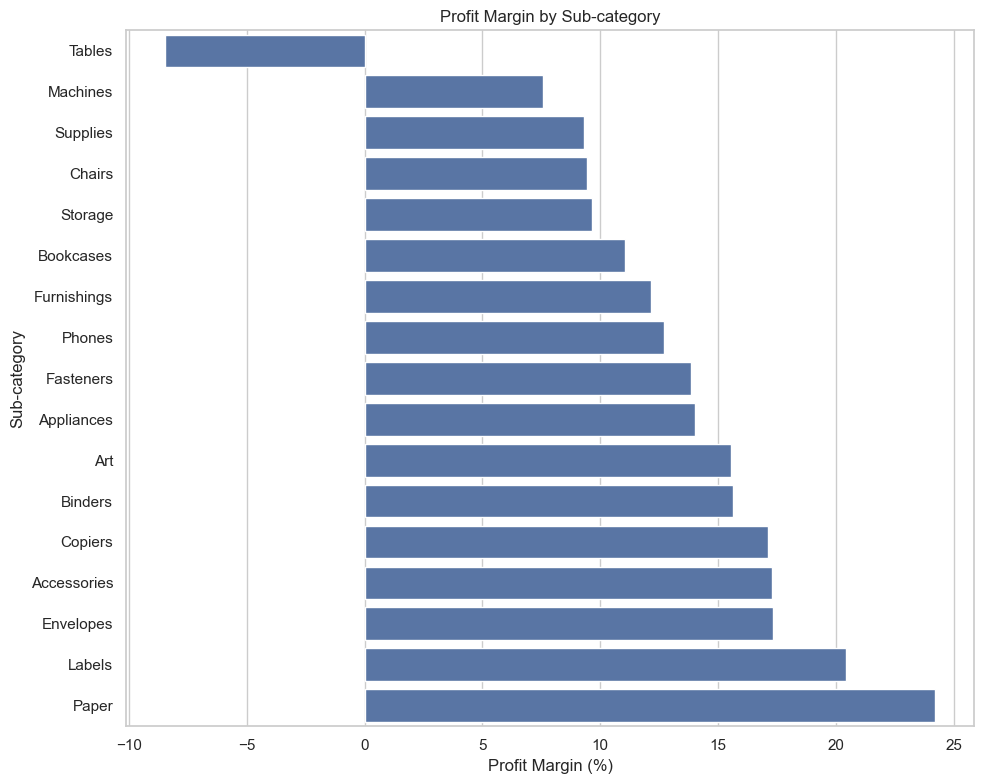

In [32]:
plot_data = (
    subcategory_profitability
    .reset_index()
    .sort_values("profit_margin")
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=plot_data,
    x="profit_margin",
    y="sub_category"
)

plt.title("Profit Margin by Sub-category")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Sub-category")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_profit_margin_by_subcategory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
segment_profitability = (
    df.groupby("segment")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
)

segment_profitability["profit_margin"] = (
    segment_profitability["profit"]
    / segment_profitability["sales"]
    * 100
)

segment_profitability.sort_values(
    "profit_margin",
    ascending=False
)

,sales,profit,quantity,profit_margin
segment,,,,
Home Office,2308792,"277,183.06",32583,12.01
Corporate,3822954,"442,113.27",53548,11.56
Consumer,6503476,"748,511.15",92111,11.51


In [34]:
region_profitability = (
    df.groupby("region")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
)

region_profitability["profit_margin"] = (
    region_profitability["profit"]
    / region_profitability["sales"]
    * 100
)

region_profitability.sort_values(
    "profit_margin",
    ascending=False
)

,sales,profit,quantity,profit_margin
region,,,,
Canada,66932,"17,796.71",833,26.59
North Asia,846991,"165,374.72",8844,19.52
Central Asia,752839,"132,480.19",7715,17.60
North,1248121,"194,598.36",18016,15.59
West,725514,"108,255.71",12266,14.92
East,678548,"91,452.12",10614,13.48
Africa,783345,"88,846.93",10559,11.34
Oceania,1098253,"121,518.84",12826,11.06
Central,2821740,"311,552.70",41755,11.04


In [35]:
monthly_analysis = (
    df.groupby("year_month")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

monthly_analysis.head()

,year_month,sales,profit,quantity
0,2011-01,98902,"8,284.78",1463
1,2011-02,91152,"12,657.77",1224
2,2011-03,145726,"15,203.90",1836
3,2011-04,116985,"12,861.31",2024
4,2011-05,146762,"12,163.67",2013


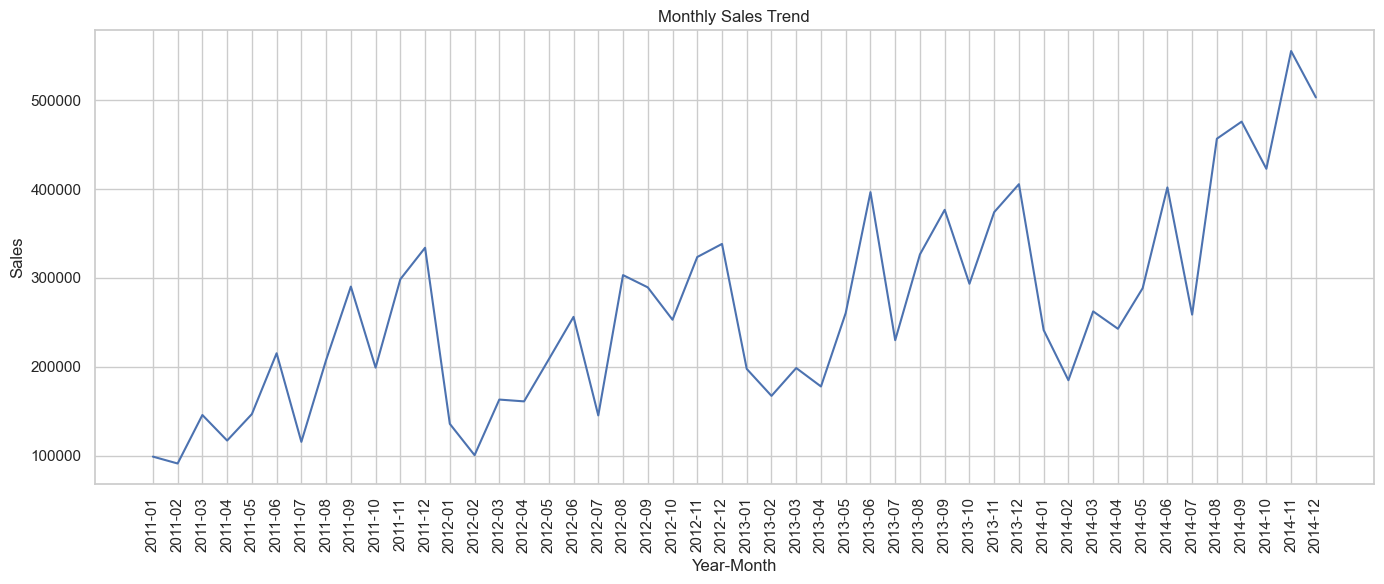

In [36]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_analysis,
    x="year_month",
    y="sales"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

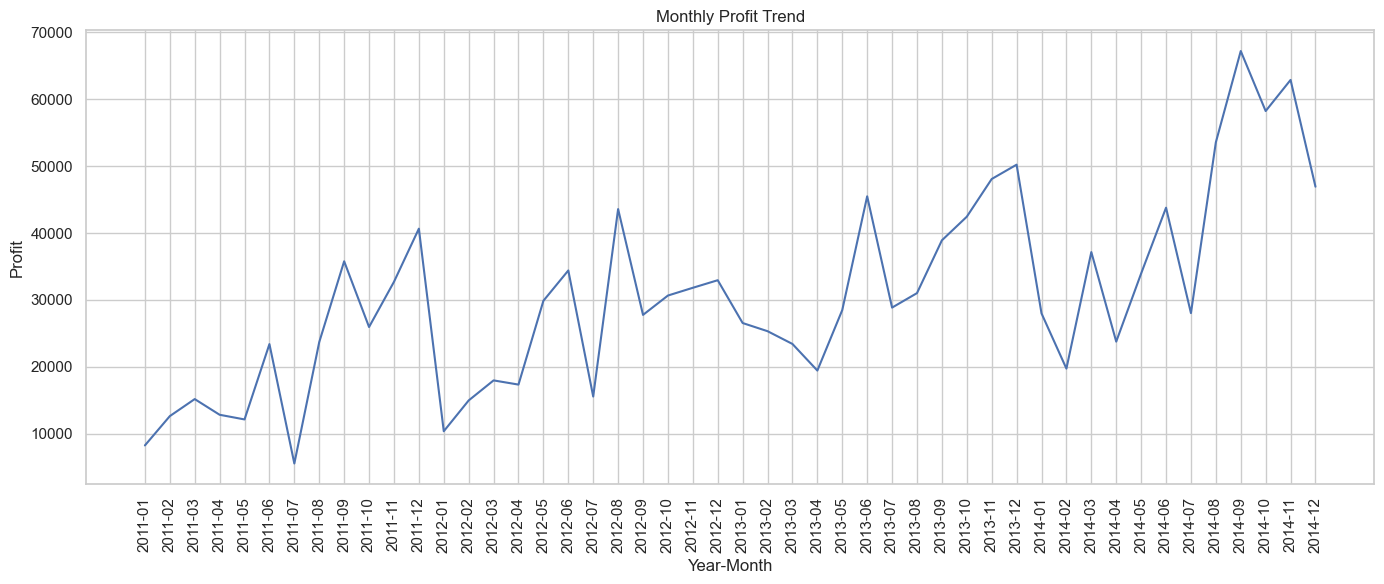

In [37]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_analysis,
    x="year_month",
    y="profit"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_monthly_profit_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

QUARTERLY ANALYSIS

In [38]:
quarterly_analysis = (
    df.groupby(["year", "quarter"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

quarterly_analysis


,year,quarter,sales,profit,quantity
0,2011,Q1,335780,"36,146.45",4523
1,2011,Q2,478961,"48,440.23",7149
2,2011,Q3,613318,"65,075.56",8516
3,2011,Q4,831510,"99,320.58",11259
4,2012,Q1,399388,"43,394.65",5555
5,2012,Q2,625611,"81,650.82",8842
6,2012,Q3,737781,"86,932.05",10342
7,2012,Q4,914699,"95,434.36",13370
8,2013,Q1,563429,"75,333.04",7191
9,2013,Q2,834873,"93,436.15",11823


In [39]:
quarterly_analysis["sales_growth_pct"] = (
    quarterly_analysis["sales"]
    .pct_change()
    * 100
)

quarterly_analysis["profit_growth_pct"] = (
    quarterly_analysis["profit"]
    .pct_change()
    * 100
)

quarterly_analysis

,year,quarter,sales,profit,quantity,sales_growth_pct,profit_growth_pct
0,2011,Q1,335780,"36,146.45",4523,NaN,NaN
1,2011,Q2,478961,"48,440.23",7149,42.64,34.01
2,2011,Q3,613318,"65,075.56",8516,28.05,34.34
3,2011,Q4,831510,"99,320.58",11259,35.58,52.62
4,2012,Q1,399388,"43,394.65",5555,-51.97,-56.31
5,2012,Q2,625611,"81,650.82",8842,56.64,88.16
6,2012,Q3,737781,"86,932.05",10342,17.93,6.47
7,2012,Q4,914699,"95,434.36",13370,23.98,9.78
8,2013,Q1,563429,"75,333.04",7191,-38.40,-21.06
9,2013,Q2,834873,"93,436.15",11823,48.18,24.03


DISCOUNT VS PROFIT

In [40]:
discount_by_category = (
    df.groupby("category")["discount"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

discount_by_category

,mean,median,min,max
category,,,,
Furniture,0.17,0.10,0.00,0.85
Office Supplies,0.14,0.00,0.00,0.80
Technology,0.14,0.00,0.00,0.70


In [41]:
discount_by_subcategory = (
    df.groupby("sub_category")["discount"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

discount_by_subcategory

,mean,median,min,max
sub_category,,,,
Tables,0.29,0.30,0.00,0.85
Binders,0.18,0.00,0.00,0.80
Machines,0.17,0.00,0.00,0.70
Chairs,0.16,0.10,0.00,0.70
Bookcases,0.15,0.10,0.00,0.70
Furnishings,0.15,0.00,0.00,0.80
Phones,0.15,0.00,0.00,0.70
Appliances,0.14,0.00,0.00,0.80
Fasteners,0.14,0.00,0.00,0.70


In [42]:
discount_by_subcategory = (
    df.groupby("sub_category")["discount"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

discount_by_subcategory

,mean,median,min,max
sub_category,,,,
Tables,0.29,0.30,0.00,0.85
Binders,0.18,0.00,0.00,0.80
Machines,0.17,0.00,0.00,0.70
Chairs,0.16,0.10,0.00,0.70
Bookcases,0.15,0.10,0.00,0.70
Furnishings,0.15,0.00,0.00,0.80
Phones,0.15,0.00,0.00,0.70
Appliances,0.14,0.00,0.00,0.80
Fasteners,0.14,0.00,0.00,0.70


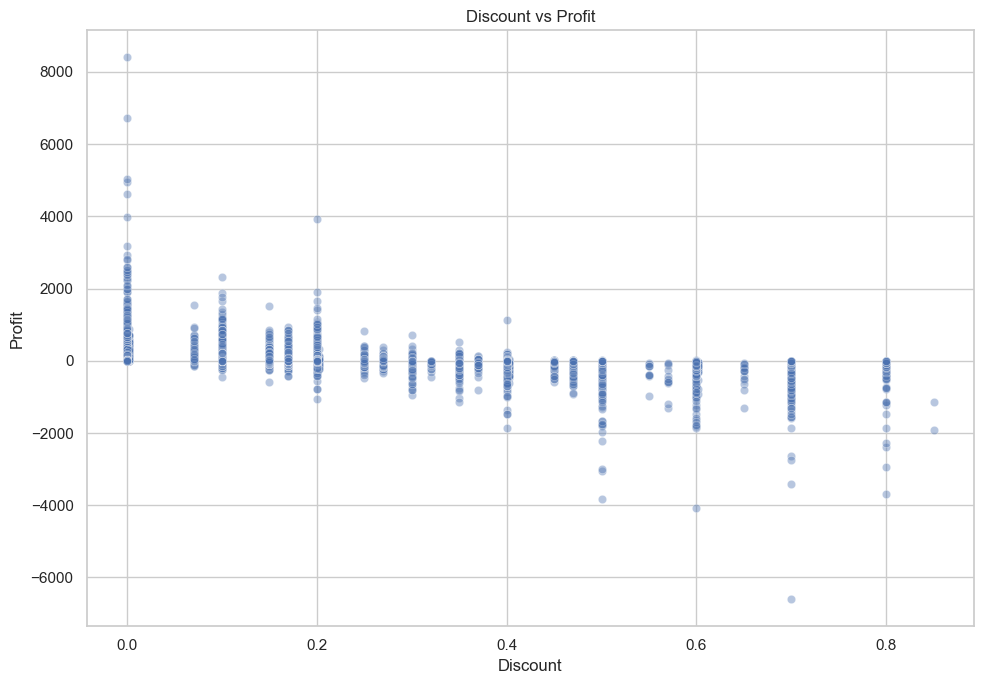

In [43]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="discount",
    y="profit",
    alpha=0.4
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_discount_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
discount_profit_corr = df["discount"].corr(df["profit"])

print(f"Correlation between discount and profit: {discount_profit_corr:.4f}")

Correlation between discount and profit: -0.3163


In [46]:
df["discount"].describe()

count   51,271.00
mean         0.14
std          0.21
min          0.00
25%          0.00
50%          0.00
75%          0.20
max          0.85
Name: discount, dtype: float64

In [47]:
high_discount_threshold = df["discount"].quantile(0.75)

print("High discount threshold:", high_discount_threshold)

High discount threshold: 0.2


In [48]:
high_discount_loss = df[
    (df["discount"] >= high_discount_threshold)
    & (df["profit"] < 0)
]

print("High-discount loss-making records:", len(high_discount_loss))

high_discount_loss[
    [
        "product_name",
        "category",
        "sub_category",
        "sales",
        "discount",
        "profit"
    ]
].sort_values("profit").head(20)

High-discount loss-making records: 11202


,product_name,category,sub_category,sales,discount,profit
31881,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,4500,0.70,"-6,599.98"
29209,"Motorola Smart Phone, Cordless",Technology,Phones,3085,0.60,"-4,088.38"
47176,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,8000,0.50,"-3,839.99"
3776,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,2178,0.80,"-3,701.89"
37125,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,2550,0.70,"-3,399.98"
24283,"Hoover Stove, White",Office Supplies,Appliances,3400,0.50,"-3,059.82"
28507,"Apple Smart Phone, Full Size",Technology,Phones,3499,0.50,"-3,009.43"
49609,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,1890,0.80,"-2,929.48"
34510,"Barricks Conference Table, Rectangular",Furniture,Tables,2171,0.70,"-2,750.28"
19251,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,1800,0.70,"-2,639.99"


In [49]:
high_discount_loss_category = (
    high_discount_loss
    .groupby("category")
    .agg(
        orders=("order_id", "count"),
        sales=("sales", "sum"),
        loss=("profit", "sum"),
        avg_discount=("discount", "mean")
    )
    .sort_values("loss")
)

high_discount_loss_category

,orders,sales,loss,avg_discount
category,,,,
Furniture,2895,951229,"-363,376.36",0.42
Technology,2026,544184,"-270,681.96",0.48
Office Supplies,6281,444390,"-252,085.25",0.53


SUB-CATEGORY ANALYSIS

In [50]:
subcategory_sales = (
    df.groupby("sub_category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_sales

sub_category
Phones         1706642
Copiers        1508370
Chairs         1500930
Bookcases      1463615
Storage        1126579
Appliances     1011081
Machines        779071
Tables          756031
Accessories     748892
Binders         461842
Furnishings     385195
Art             372055
Paper           244281
Supplies        243090
Envelopes       170875
Fasteners        83240
Labels           73433
Name: sales, dtype: int64

In [51]:
subcategory_profit = (
    df.groupby("sub_category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_profit

sub_category
Copiers       258,174.35
Phones        216,705.25
Bookcases     161,703.19
Chairs        141,732.31
Appliances    141,680.59
Accessories   129,568.74
Storage       108,537.28
Binders        72,272.01
Paper          59,195.24
Machines       58,850.70
Art            57,921.90
Furnishings    46,858.64
Envelopes      29,595.03
Supplies       22,594.05
Labels         15,009.63
Fasteners      11,522.02
Tables        -64,113.45
Name: profit, dtype: float64

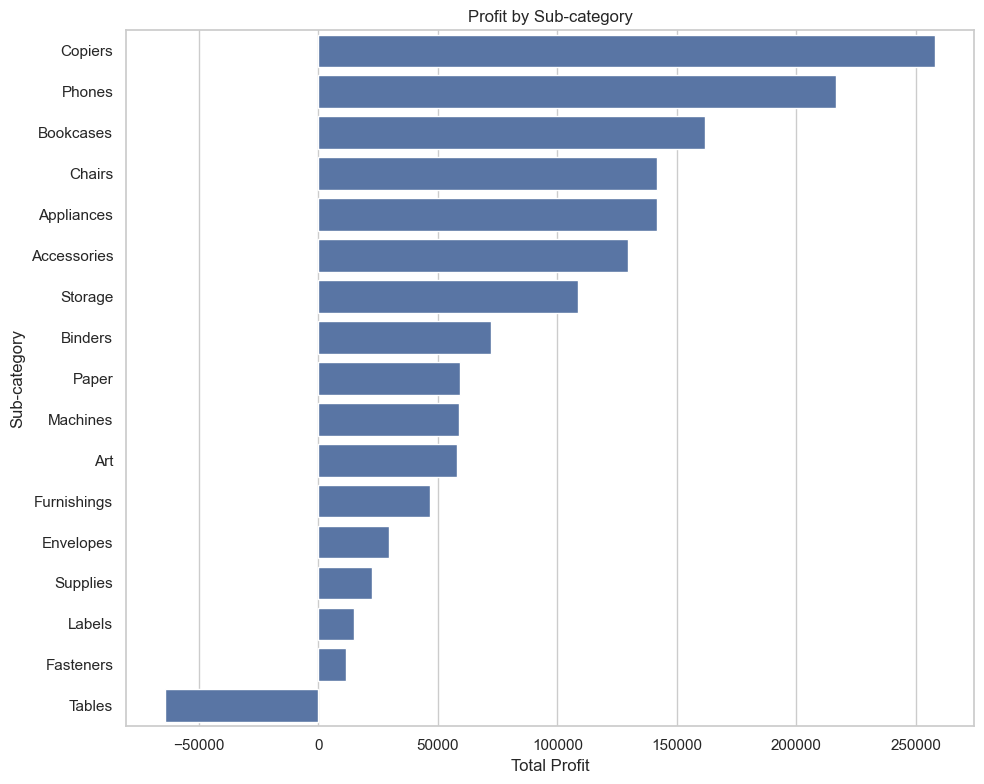

In [52]:
plt.figure(figsize=(10, 8))

plot_data = subcategory_profit.reset_index()

sns.barplot(
    data=plot_data,
    x="profit",
    y="sub_category"
)

plt.title("Profit by Sub-category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-category")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_profit_by_subcategory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
top_10_subcategories = (
    subcategory_profit
    .head(10)
    .reset_index()
)

top_10_subcategories

,sub_category,profit
0,Copiers,"258,174.35"
1,Phones,"216,705.25"
2,Bookcases,"161,703.19"
3,Chairs,"141,732.31"
4,Appliances,"141,680.59"
5,Accessories,"129,568.74"
6,Storage,"108,537.28"
7,Binders,"72,272.01"
8,Paper,"59,195.24"
9,Machines,"58,850.70"


In [56]:
def outlier_summary(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]

    return {
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": (len(outliers) / len(dataframe)) * 100
    }

In [57]:
outlier_columns = [
    "sales",
    "profit",
    "discount",
    "quantity",
    "shipping_cost",
    "shipping_days"
]

outlier_results = pd.DataFrame(
    [
        outlier_summary(df, column)
        for column in outlier_columns
    ]
)

outlier_results

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,sales,31.00,251.00,220.00,-299.00,581.00,5650,11.02
1,profit,0.00,36.80,36.80,-55.21,92.01,9748,19.01
2,discount,0.00,0.20,0.20,-0.30,0.50,4170,8.13
3,quantity,2.00,5.00,3.00,-2.50,9.50,876,1.71
4,shipping_cost,2.61,24.45,21.84,-30.14,57.20,5903,11.51
5,shipping_days,3.00,5.00,2.00,0.00,8.00,0,0.00


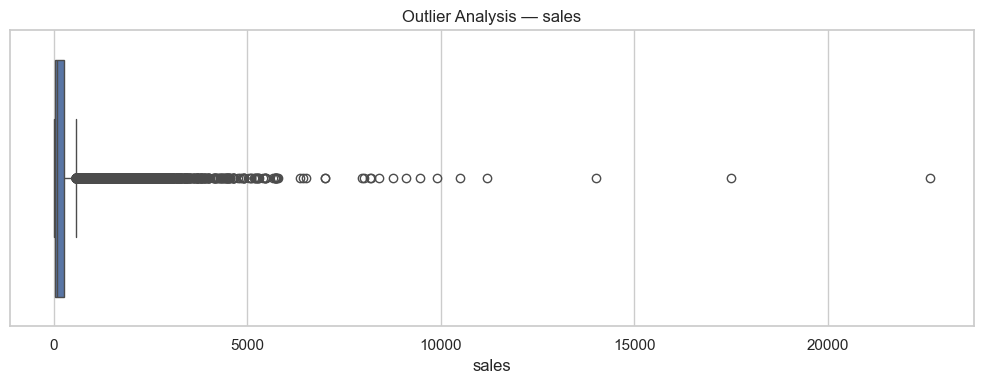

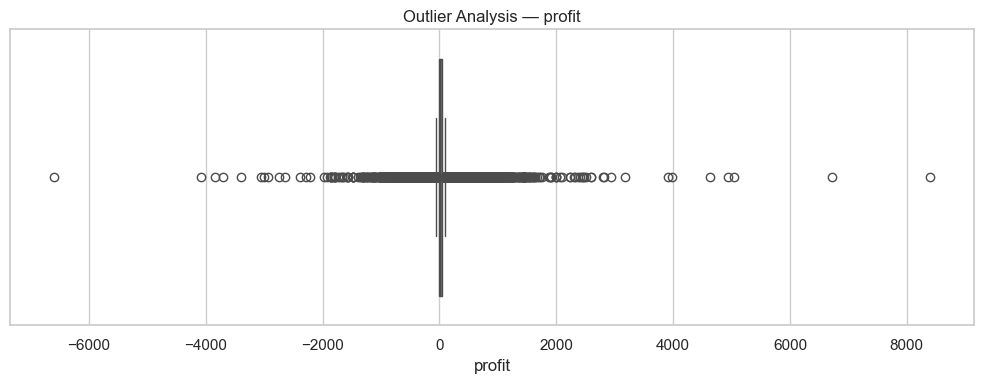

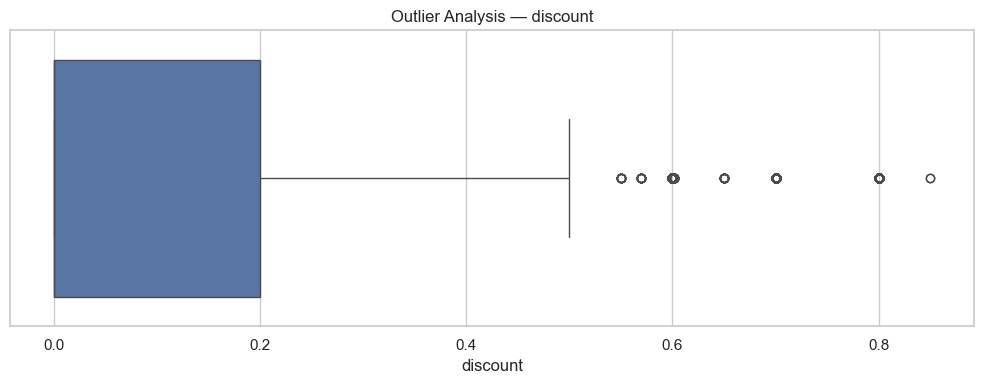

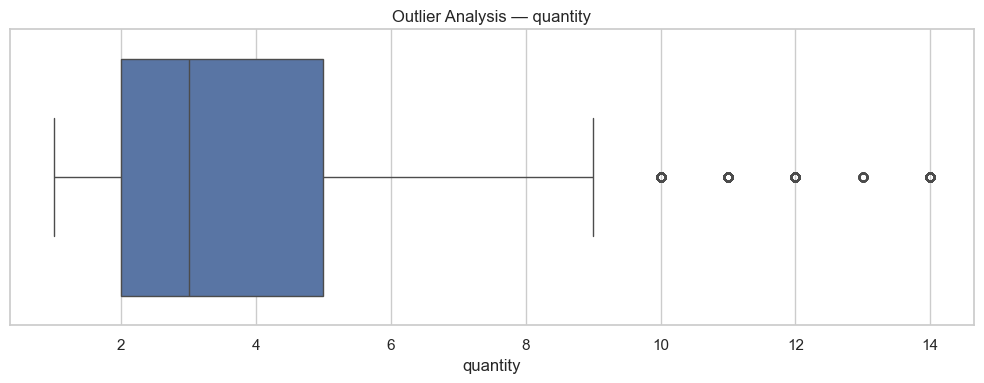

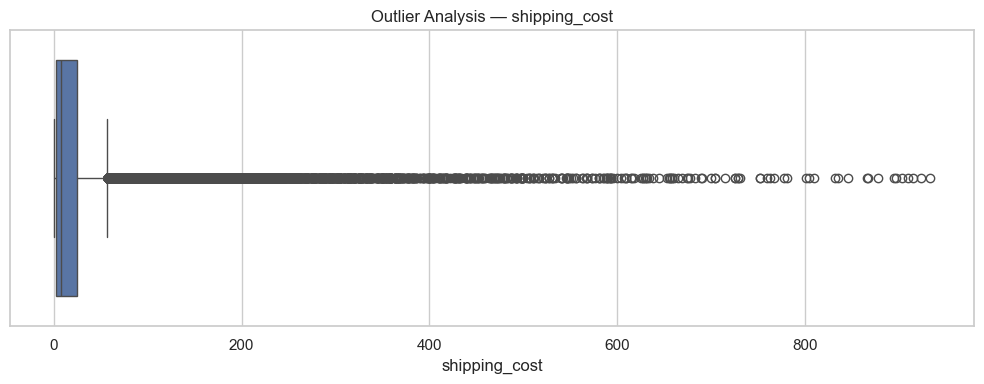

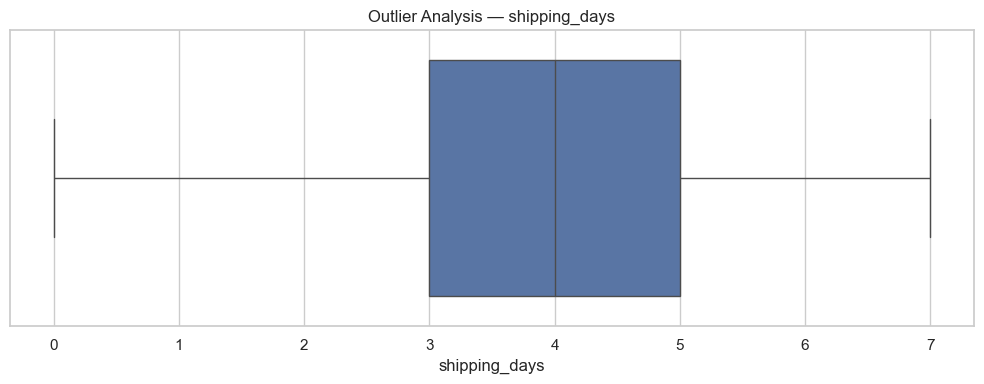

In [58]:
for column in outlier_columns:
    plt.figure(figsize=(10, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Outlier Analysis — {column}")
    plt.xlabel(column)

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"04_outlier_{column}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [59]:
sales_outliers = df[
    (df["sales"] < (
        df["sales"].quantile(0.25)
        - 1.5 * (
            df["sales"].quantile(0.75)
            - df["sales"].quantile(0.25)
        )
    ))
    |
    (df["sales"] > (
        df["sales"].quantile(0.75)
        + 1.5 * (
            df["sales"].quantile(0.75)
            - df["sales"].quantile(0.25)
        )
    ))
]

sales_outliers[
    [
        "order_id",
        "product_name",
        "category",
        "sales",
        "quantity",
        "discount",
        "profit"
    ]
].sort_values("sales", ascending=False).head(20)

,order_id,product_name,category,sales,quantity,discount,profit
1103,CA-2011-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638,6,0.50,"-1,811.08"
29527,CA-2013-118689,Canon imageCLASS 2200 Advanced Copier,Technology,17500,5,0.00,"8,399.98"
36234,CA-2014-140151,Canon imageCLASS 2200 Advanced Copier,Technology,14000,4,0.00,"6,719.98"
46506,CA-2014-127180,Canon imageCLASS 2200 Advanced Copier,Technology,11200,4,0.20,"3,919.99"
48078,CA-2014-166709,Canon imageCLASS 2200 Advanced Copier,Technology,10500,3,0.00,"5,039.99"
33008,CA-2013-117121,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,9893,13,0.00,"4,946.37"
5523,CA-2011-116904,Ibico EPK-21 Electric Binding System,Office Supplies,9450,5,0.00,"4,630.48"
22480,US-2013-107440,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,9100,7,0.00,"2,365.98"
20690,CA-2013-158841,HP Designjet T520 Inkjet Large Format Printer ...,Technology,8750,5,0.00,"2,799.98"
23572,CA-2013-143714,Canon imageCLASS 2200 Advanced Copier,Technology,8400,4,0.40,"1,120.00"


In [60]:
profit_Q1 = df["profit"].quantile(0.25)
profit_Q3 = df["profit"].quantile(0.75)
profit_IQR = profit_Q3 - profit_Q1

profit_lower = profit_Q1 - 1.5 * profit_IQR
profit_upper = profit_Q3 + 1.5 * profit_IQR

profit_outliers = df[
    (df["profit"] < profit_lower) |
    (df["profit"] > profit_upper)
]

profit_outliers[
    [
        "order_id",
        "product_name",
        "category",
        "sales",
        "discount",
        "profit"
    ]
].sort_values("profit").head(20)

,order_id,product_name,category,sales,discount,profit
31881,CA-2013-108196,Cubify CubeX 3D Printer Double Head Print,Technology,4500,0.70,"-6,599.98"
29209,TU-2013-9400,"Motorola Smart Phone, Cordless",Technology,3085,0.60,"-4,088.38"
47176,US-2014-168116,Cubify CubeX 3D Printer Triple Head Print,Technology,8000,0.50,"-3,839.99"
3776,CA-2011-169019,GBC DocuBind P400 Electric Binding System,Office Supplies,2178,0.80,"-3,701.89"
37125,CA-2014-134845,Lexmark MX611dhe Monochrome Laser Printer,Technology,2550,0.70,"-3,399.98"
24283,IT-2013-3695467,"Hoover Stove, White",Office Supplies,3400,0.50,"-3,059.82"
28507,ID-2013-12295,"Apple Smart Phone, Full Size",Technology,3499,0.50,"-3,009.43"
49609,US-2014-122714,Ibico EPK-21 Electric Binding System,Office Supplies,1890,0.80,"-2,929.48"
34510,LH-2014-5390,"Barricks Conference Table, Rectangular",Furniture,2171,0.70,"-2,750.28"
19251,CA-2012-147830,Cubify CubeX 3D Printer Double Head Print,Technology,1800,0.70,"-2,639.99"


In [61]:
print("Final dataset shape:", df.shape)

print("\nNew Features:")
print(engineered_columns)

print("\nMissing values in new features:")
print(df[engineered_columns].isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Final dataset shape: (51271, 29)

New Features:
['shipping_days', 'profit_margin', 'year_month', 'quarter', 'year', 'month', 'month_name']

Missing values in new features:
shipping_days    0
profit_margin    1
year_month       0
quarter          0
year             0
month            0
month_name       0
dtype: int64

Duplicate rows:
0


In [62]:
df[
    [
        "order_id",
        "order_date",
        "ship_date",
        "shipping_days",
        "sales",
        "profit",
        "profit_margin",
        "year_month",
        "quarter"
    ]
].head(15)

,order_id,order_date,ship_date,shipping_days,sales,profit,profit_margin,year_month,quarter
0,AG-2011-2040,2011-01-01,2011-01-06,5,408,106.14,26.01,2011-01,Q1
1,IN-2011-47883,2011-01-01,2011-01-08,7,120,36.04,30.03,2011-01,Q1
2,HU-2011-1220,2011-01-01,2011-01-05,4,66,29.64,44.91,2011-01,Q1
3,IT-2011-3647632,2011-01-01,2011-01-05,4,45,-26.05,-57.90,2011-01,Q1
4,IN-2011-47883,2011-01-01,2011-01-08,7,114,37.77,33.13,2011-01,Q1
5,IN-2011-47883,2011-01-01,2011-01-08,7,55,15.34,27.89,2011-01,Q1
6,CA-2011-1510,2011-01-02,2011-01-06,4,314,3.12,0.99,2011-01,Q1
7,IN-2011-79397,2011-01-03,2011-01-03,0,276,110.41,40.00,2011-01,Q1
8,ID-2011-80230,2011-01-03,2011-01-09,6,912,-319.46,-35.03,2011-01,Q1
9,IZ-2011-4680,2011-01-03,2011-01-07,4,667,253.32,37.98,2011-01,Q1


In [63]:
df.to_csv(ENGINEERED_FILE, index=False)

print("\nFinal shape:", df.shape)


Final shape: (51271, 29)
